# Queda Livre: Modelagem Matemática e Implementação Computacional

Este notebook segue o roteiro proposto para o trabalho prático de modelagem matemática da Queda Livre, unindo teoria, programação e análise de resultados. Cada etapa é explicada em detalhes, com células Markdown e código Python, além de salvar os dados e gráficos gerados.

## 1. Configurações Iniciail

In [131]:
# Organização da criação das pastas para dados e gráficos (executar uma vez)
from pathlib import Path
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Diretório base do projeto (pasta do notebook)
base_dir = Path().resolve()

# Diretórios principais
dados_dir = base_dir / 'dados'
graficos_dir = base_dir / 'graficos'

# Subpastas de gráficos
graficos_queda_livre_dir = graficos_dir / 'queda_livre'
graficos_corpo_rigido_dir = graficos_dir / 'corpo_rigido'
graficos_resistencia_ar_dir = graficos_dir / 'queda_livre_resistencia_ar'
graficos_acuracia_dir = graficos_dir / 'acuracia'

# Subpastas de dados
input_dir = dados_dir / 'input'
output_dir = dados_dir / 'output'
output_queda_livre_dir = output_dir / 'queda_livre'
output_corpo_rigido_dir = output_dir / 'corpo_rigido'
output_resistencia_ar_dir = output_dir / 'queda_livre_resistencia_ar'
output_acuracia_dir = output_dir / 'acuracia'

# Lista de todas as pastas a serem criadas
pastas = [
    dados_dir, graficos_dir,
    graficos_queda_livre_dir, graficos_corpo_rigido_dir, graficos_resistencia_ar_dir, graficos_acuracia_dir,
    input_dir, output_dir,
    output_queda_livre_dir, output_corpo_rigido_dir, output_resistencia_ar_dir, output_acuracia_dir
]
for pasta in pastas:
    pasta.mkdir(exist_ok=True, parents=True)

print(f'Pastas criadas ou já existentes:\n{dados_dir}\n{graficos_dir}')
print('Subpastas de gráficos:')
print(graficos_queda_livre_dir)
print(graficos_corpo_rigido_dir)
print(graficos_resistencia_ar_dir)
print(graficos_acuracia_dir)
print('Subpastas de dados:')
print(input_dir)
print(output_dir)
print(output_queda_livre_dir)
print(output_corpo_rigido_dir)
print(output_resistencia_ar_dir)
print(output_acuracia_dir)

# Função para salvar DataFrame de saída normalmente
def salvar_dados(df, pasta_destino, nome_arquivo):
    saida_csv = os.path.join(pasta_destino, nome_arquivo) if isinstance(pasta_destino, str) else pasta_destino / nome_arquivo
    df.to_csv(saida_csv, index=False, float_format='%.4f')
    print(f'Resultado salvo em: {saida_csv}')


Pastas criadas ou já existentes:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos
Subpastas de gráficos:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\queda_livre
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\corpo_rigido
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\queda_livre_resistencia_ar
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia
Subpastas de dados:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\da

## 1. Criação das Funções

### 1.1 Função para simular a queda livre usando o método de Euler

In [132]:
# Função para simular a queda livre usando o método de Euler
# Agora retorna DataFrame padronizado

def simula_queda_livre(H, V, g, dt):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt)
        a.append(-g)
    if x[-1] < 0:
        x[-1] = 0
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

### 1.2. Função para Modelagem de corpo rígido em queda livre com resistência 

#### 1.2.2 Função com resistência linear

In [133]:
def simula_queda_livre_linear(H, V, g, dt, k, t_max):
    """
    Simula a queda livre com resistência do ar linear (F = -k*v).
    Parâmetros:
        H: altura inicial (m)
        V: velocidade inicial (m/s)
        g: gravidade (m/s²)
        dt: passo de tempo (s)
        k: coeficiente de resistência linear (1/s)
        t_max: tempo máximo de simulação (s)
    Retorna:
        DataFrame com tempo, posição, velocidade e aceleração
    """
    import numpy as np
    import pandas as pd

    n = int(t_max / dt) + 1
    t = np.linspace(0, t_max, n)
    x = np.zeros(n)
    v = np.zeros(n)
    a = np.zeros(n)
    x[0] = H
    v[0] = V
    for i in range(1, n):
        a[i-1] = -g - k * v[i-1]
        v[i] = v[i-1] + a[i-1] * dt
        x[i] = x[i-1] + v[i-1] * dt
        if x[i] <= 0:
            x[i] = 0
            v[i] = 0
            a[i] = 0
            t = t[:i+1]
            x = x[:i+1]
            v = v[:i+1]
            a = a[:i+1]
            break
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

#### 1.2.2 Função com resistência quadrática

In [134]:
# Modelagem de corpo rígido em queda livre com resistência quadrática

def simula_queda_livre_quadratica(H, m, Cd, A, rho, dt, t_max):
    """
    Simula a queda livre de um corpo rígido com resistência quadrática.
    Parâmetros:
        H: altura inicial (m)
        m: massa (kg)
        Cd: coeficiente de arrasto
        A: área de contato (m²)
        rho: densidade do ar (kg/m³)
        dt: passo de tempo (s)
        t_max: tempo máximo de simulação (s)
    Retorna:
        DataFrame com tempo, posição, velocidade e aceleração
    """
    g = 9.81
    n = int(t_max / dt) + 1
    t = np.linspace(0, t_max, n)
    x = np.zeros(n)
    v = np.zeros(n)
    a = np.zeros(n)
    x[0] = H
    v[0] = 0
    for i in range(1, n):
        Fr = 0.5 * Cd * rho * A * v[i-1]**2
        a[i-1] = g - Fr / m
        v[i] = v[i-1] + a[i-1] * dt
        x[i] = x[i-1] - v[i] * dt
        if x[i] <= 0:
            x[i] = 0
            v[i] = 0
            a[i] = 0
            t = t[:i+1]
            x = x[:i+1]
            v = v[:i+1]
            a = a[:i+1]
            break
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

### 1.3. Função para simular queda livre com resistência do ar proporcional à velocidade

In [135]:
# Função para simular queda livre com resistência do ar proporcional à velocidade
# Agora retorna DataFrame padronizado

def simula_queda_livre_resistencia(H, V, g, dt, c):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g + c*v[-1]]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt + c*v[-1]*dt)
        a.append(-g + c*v[-1])
    if x[-1] < 0:
        x[-1] = 0
    df = pd.DataFrame({'tempo': t, 'posicao': x, 'velocidade': v, 'aceleracao': a})
    return df

### 1.4. Função para Apresentação dos Gráficos: Posição, Velocidade, Aceleração em função do Tempo e acurácia

In [136]:
def plotar_grafico_posicao_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        x = resultados[dt]['x']
        plt.plot(t, x, label=f'dt = {dt} s')  # unidade explícita
    plt.xlabel('Tempo (s)')
    plt.ylabel('Posição (m)')
    plt.title(f'Posição x Tempo ({titulo})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_grafico_velocidade_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        v = resultados[dt]['v']
        v_abs = [abs(vi) for vi in v]
        plt.plot(t, v_abs, label=f'dt = {dt} s')  # unidade explícita
    plt.xlabel('Tempo (s)')
    plt.ylabel('Velocidade (m/s)')
    plt.title(f'Velocidade x Tempo ({titulo})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_grafico_aceleracao_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        g = -9.81
        aceleracao = [g for _ in t]
        plt.plot(t, aceleracao, label=f'dt = {dt} s')  # unidade explícita
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração (m/s²)')
    plt.title(f'Aceleração x Tempo ({titulo})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

def plotar_acuracia_dt_csv(caminho_csv, titulo, nome_arquivo, graficos_dir):
    df = pd.read_csv(caminho_csv)
    dt_list = df['dt (s)']  # Atualizado para o nome com unidade
    erros = df['erro_relativo']
    plt.figure(figsize=(8,5))
    plt.plot(dt_list, erros, marker='o', linestyle='-', color='tab:blue')
    plt.xlabel('Passo de tempo (dt) [s]')
    plt.ylabel('Erro relativo (v_final numérico vs. analítico)')
    plt.title(titulo)
    plt.grid(True)
    plt.tight_layout()
    caminho = graficos_dir / nome_arquivo
    plt.savefig(caminho)
    plt.show()
    print(f'Gráfico salvo em: {caminho}')

### 1.5. Função Esutdo da acurácia Acurácia em Função do Tamanhao do Passo

In [137]:
def vfinal_analitico_sem_resistencia(V, g, t):
    return V - g * t

def vfinal_analitico_com_resistencia(V, g, c, t):
    return (V + g/c) * np.exp(c * t) - g/c

# Função para calcular erro relativo
def erro_relativo(v_num, v_ana):
    return abs((v_num - v_ana) / v_ana) if v_ana != 0 else np.nan

# Função para simular, calcular analítico e erro para uma lista de dt
def acuracia_vfinal(simulador, v_analitico_func, H, V, g, dt_list, c=None):
    v_finais = []
    t_finais = []
    v_analiticos = []
    erros = []
    for dt in dt_list:
        if c is not None:
            df = simulador(H, V, g, dt, c)
            t = df['tempo']
            v = df['velocidade']
            v_ana = v_analitico_func(V, g, c, t.iloc[-1])
        else:
            df = simulador(H, V, g, dt)
            t = df['tempo']
            v = df['velocidade']
            v_ana = v_analitico_func(V, g, t.iloc[-1])
        v_finais.append(v.iloc[-1])
        t_finais.append(t.iloc[-1])
        v_analiticos.append(v_ana)
        erros.append(erro_relativo(v.iloc[-1], v_ana))
    return v_finais, t_finais, v_analiticos, erros


def simula_acuracia_parametrizada(H, V, g, dt_inicial, dt_final, dt_step, c_list, output_acuracia_dir):
    import numpy as np
    import pandas as pd

    dt_list = np.arange(dt_inicial, dt_final + dt_step, dt_step).tolist()

    # --- SEM resistência do ar ---
    v_finais, t_finais, v_analiticos, erros = acuracia_vfinal(
        simula_queda_livre, vfinal_analitico_sem_resistencia, H, V, g, dt_list
    )
    df_sem = pd.DataFrame({
        'dt (s)': dt_list,
        'tempo_final (s)': t_finais,
        'v_final_num (m/s)': v_finais,
        'v_final_analitico (m/s)': v_analiticos,
        'erro_relativo': erros
    })
    salvar_dados(df_sem, output_acuracia_dir, 'acuracia_sem_resistencia.csv')

    # --- COM resistência do ar ---
    for c in c_list:
        v_finais, t_finais, v_analiticos, erros = acuracia_vfinal(
            simula_queda_livre_resistencia, vfinal_analitico_com_resistencia, H, V, g, dt_list, c
        )
        df_com = pd.DataFrame({
            'dt (s)': dt_list,
            'tempo_final (s)': t_finais,
            'v_final_num (m/s)': v_finais,
            'v_final_analitico (m/s)': v_analiticos,
            'erro_relativo': erros
        })
        nome_arquivo = f'acuracia_com_resistencia_c_{str(c).replace(".", "_")}.csv'
        salvar_dados(df_com, output_acuracia_dir, nome_arquivo)

## 2. Implementação dos Modelos


In [138]:
# ==== Definição dos parâmetros iniciais (usados em todos os casos) ====
import pandas as pd
import numpy as np

H = 100.0  # altura inicial (m)
V = 0.0    # velocidade inicial (m/s)
g = 9.81   # gravidade (m/s²)
dt_list = [1.0, 0.5, 0.1, 0.01, 0.001]  # lista de passos de tempo
t_max = 20  # tempo máximo de simulação (s)

# ==== Entrada para queda livre sem resistência ====
df_entradas = pd.DataFrame({
    'Altura': H,
    'Velocidade Inicial': V,
    'Gravidade': g,
    'Passo de Tempo': dt_list
})
salvar_dados(df_entradas, input_dir, 'entrada_queda_livre.csv')

# ==== Entrada para resistência linear (corpo rígido) ====
k = 1.0  # coeficiente de resistência linear (1/s)
entradas_linear = [
    {
        'Modelo': 'resistencia_linear',
        'Altura (m)': H,
        'Velocidade Inicial (m/s)': V,
        'Gravidade (m/s²)': g,
        'k (1/s)': k,
        't_max (s)': t_max,
        'dt (s)': dt
    }
    for dt in dt_list
]

df_entradas_linear = pd.DataFrame(entradas_linear)
salvar_dados(df_entradas_linear, input_dir, 'entrada_queda_livre_linear.csv')

# ==== Entrada para resistência quadrática (corpo rígido) ====
m = 1.0      # massa (kg)
Cd = 0.47    # coeficiente de arrasto (esfera)
A = 0.01     # área de contato (m²)
rho = 1.225  # densidade do ar (kg/m³)
entradas_quadratica = [
    {
        'Modelo': 'resistencia_quadratica',
        'Altura (m)': H,
        'Massa (kg)': m,
        'Cd': Cd,
        'A (m²)': A,
        'Rho (kg/m³)': rho,
        't_max (s)': t_max,
        'dt (s)': dt
    }
    for dt in dt_list
]
df_entradas_quadratica = pd.DataFrame(entradas_quadratica)
salvar_dados(df_entradas_quadratica, input_dir, 'entrada_queda_livre_quadratica.csv')

# ==== Entrada para resistência do ar proporcional à velocidade (modelo alternativo) ====
c_list = [0.01, 0.1, 2, 10]  # coeficiente de resistência do ar (linear)
entradas_simulacoes_resistencia = [
    {
        'modelo': 'resistencia_linear',
        'H (m)': H,
        'V (m/s)': V,
        'g (m/s²)': g,
        'dt (s)': dt,
        'c (1/s)': c,
    }
    for c in c_list for dt in dt_list
]
df_entradas_simulacoes_resistencia = pd.DataFrame(entradas_simulacoes_resistencia)
salvar_dados(df_entradas_simulacoes_resistencia, input_dir, 'entrada_queda_livre_resistencia.csv')


# Defina o intervalo e passo de dt conforme desejado
dt_inicial = 0.001
dt_final = 1.0
dt_step = 0.001

# Salvar entrada para o caso SEM resistência
df_entrada_sem = pd.DataFrame({
    'Altura (m)': [H],
    'Velocidade Inicial (m/s)': [V],
    'Gravidade (m/s²)': [g],
    'dt_inicial': [dt_inicial],
    'dt_final': [dt_final],
    'dt_step': [dt_step]
})
df_entrada_sem.to_csv(input_dir / 'entrada_acuracia_sem_resistencia.csv', index=False)

# Salvar entrada para o caso COM resistência (uma linha para cada c)
entradas_com = []
for c in c_list:
    entradas_com.append({
        'Altura (m)': H,
        'Velocidade Inicial (m/s)': V,
        'Gravidade (m/s²)': g,
        'c (1/s)': c,
        'dt_inicial': dt_inicial,
        'dt_final': dt_final,
        'dt_step': dt_step
    })
df_entrada_com = pd.DataFrame(entradas_com)
df_entrada_com.to_csv(input_dir / 'entrada_acuracia_com_resistencia.csv', index=False)

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_linear.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_quadratica.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\entrada_queda_livre_resistencia.csv


### 2.1 Implementação Básica do Modelo de Queda Livre

Neste passo, vamos implementar o modelo discreto da queda livre usando o método de Euler. O objetivo é calcular, passo a passo, a posição e a velocidade de uma pedra até ela atingir o solo.

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre\saida_queda_livre_dt_1_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre\saida_queda_livre_dt_0_5.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre\saida_queda_livre_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre\saida_queda_livre_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre\saida_queda_livre_dt_0_001.csv


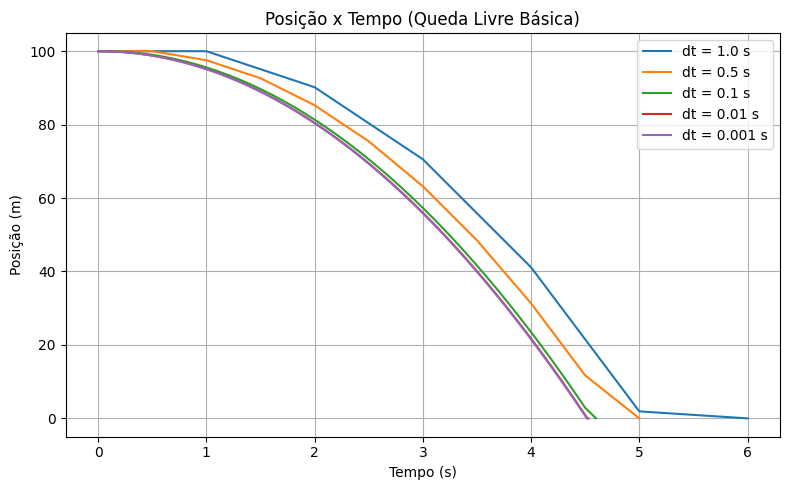

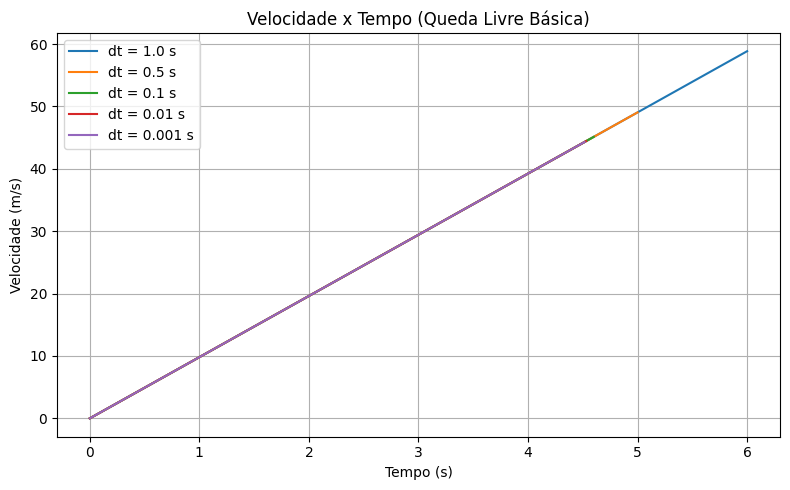

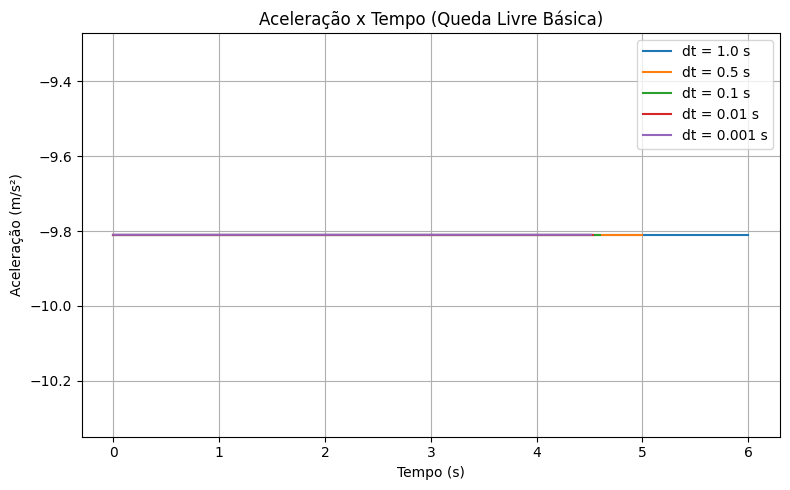

In [139]:
resultados_csv = {}
for dt in dt_list:
    df = simula_queda_livre(H, V, g, dt)
    resultados_csv[dt] = {
        't': df['tempo'].tolist(),
        'x': df['posicao'].tolist(),
        'v': df['velocidade'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_dt_{str(dt).replace(".", "_")}.csv'
    salvar_dados(df, output_queda_livre_dir, nome_arquivo)

# Chama as funções separadas para plotar e salvar cada gráfico
plotar_grafico_posicao_tempo(resultados_csv, dt_list, graficos_queda_livre_dir, 'Queda Livre Básica' , 'grafico_posicao_tempo_multidt.png')
plotar_grafico_velocidade_tempo(resultados_csv, dt_list, graficos_queda_livre_dir, 'Queda Livre Básica', 'grafico_velocidade_tempo_multidt.png')
plotar_grafico_aceleracao_tempo(resultados_csv, dt_list, graficos_queda_livre_dir, 'Queda Livre Básica', 'grafico_aceleracao_tempo_multidt.png')

### 2.2. Implementação do Modelo Corpo Rígido em Queda Livre


#### 2.2.1. Simulação com Resistência Linear

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_linear_dt_1_0_k_1_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_linear_dt_0_5_k_1_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_linear_dt_0_1_k_1_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_linear_dt_0_01_k_1_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_linear_dt_0_001_k_1_0.csv


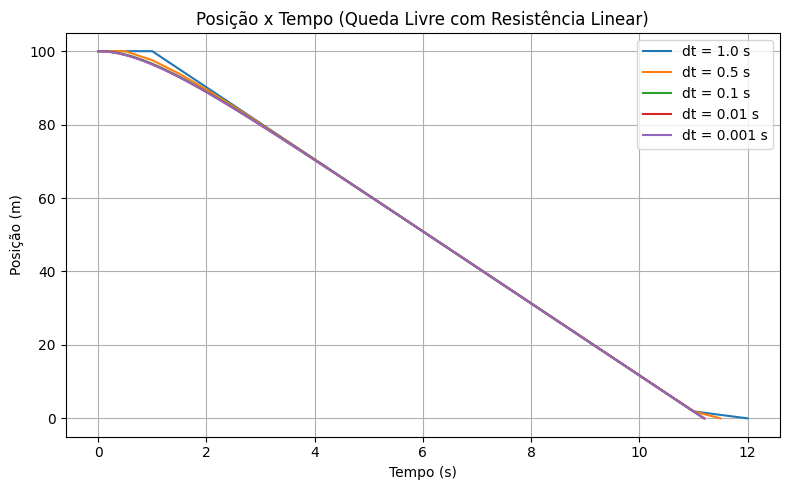

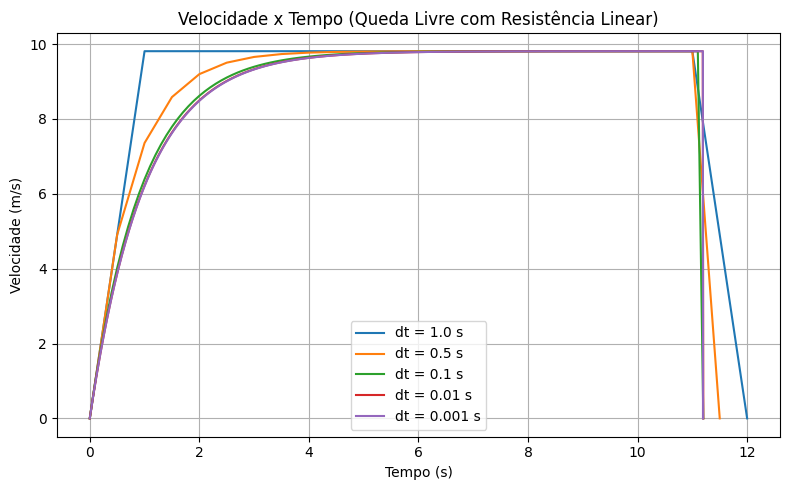

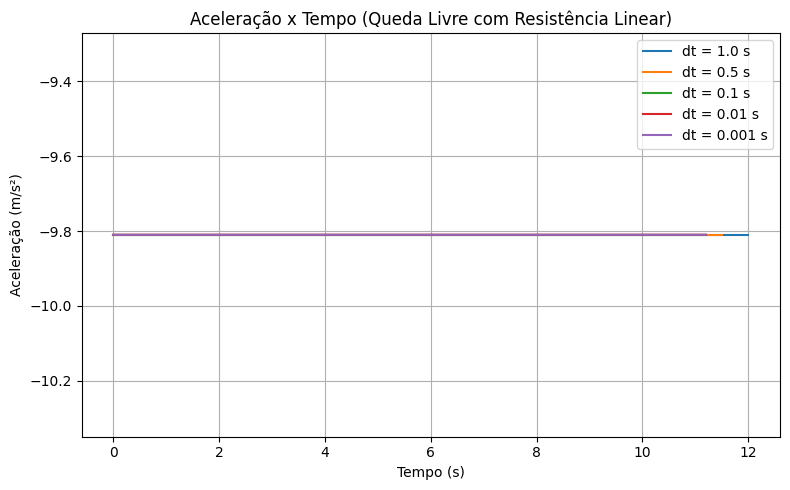

In [140]:
# Simulação, salvamento e preparação para plotagem (tudo junto) para resistência linear com k fixo
resultados_csv_linear = {}
for dt in dt_list:
    df_linear = simula_queda_livre_linear(H, V, g, dt, k, t_max)
    resultados_csv_linear[dt] = {
        't': df_linear['tempo'].tolist(),
        'x': df_linear['posicao'].tolist(),
        'v': df_linear['velocidade'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_linear_dt_{str(dt).replace(".", "_")}_k_{str(k).replace(".", "_")}.csv'
    salvar_dados(df_linear, output_corpo_rigido_dir, nome_arquivo)

# Plota para o valor único de k
plotar_grafico_posicao_tempo(resultados_csv_linear, dt_list, graficos_corpo_rigido_dir,'Queda Livre com Resistência Linear', f'grafico_posicao_tempo_linear_k_{str(k).replace(".", "_")}.png')
plotar_grafico_velocidade_tempo(resultados_csv_linear, dt_list, graficos_corpo_rigido_dir, 'Queda Livre com Resistência Linear', f'grafico_velocidade_tempo_linear_k_{str(k).replace(".", "_")}.png')
plotar_grafico_aceleracao_tempo(resultados_csv_linear, dt_list, graficos_corpo_rigido_dir, 'Queda Livre com Resistência Linear', f'grafico_aceleracao_tempo_linear_k_{str(k).replace(".", "_")}.png')

#### 2.2.1. Simulação com Resistência Quadrática

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_quadratica_dt_1_0.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_quadratica_dt_0_5.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_quadratica_dt_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_quadratica_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\corpo_rigido\saida_queda_livre_quadratica_dt_0_001.csv


FileNotFoundError: [Errno 2] No such file or directory: 'Queda Livre com Resistência Quadrática\\grafico_posicao_tempo_quadratica_multidt.png'

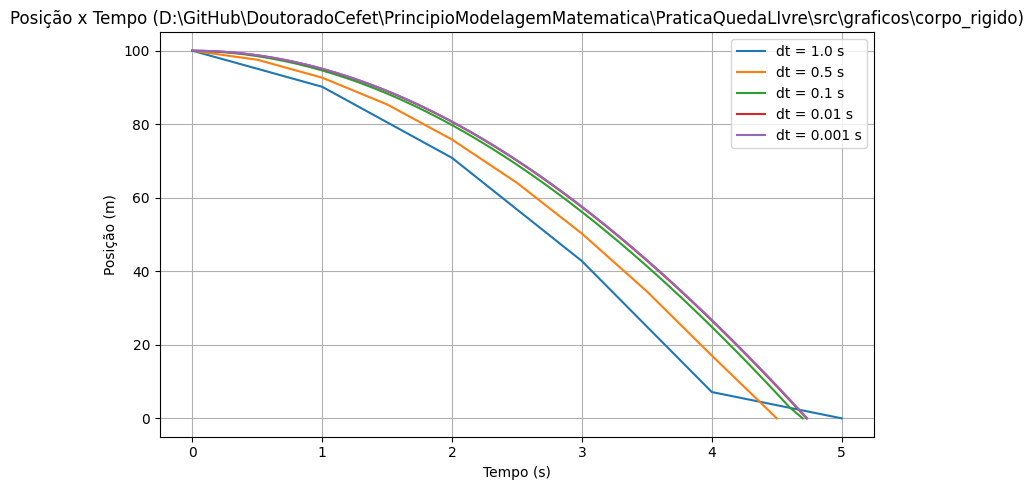

In [141]:
resultados_csv_quadratica = {}
for dt in dt_list:
    df_quadratica = simula_queda_livre_quadratica(H, m, Cd, A, rho, dt, t_max)
    resultados_csv_quadratica[dt] = {
        't': df_quadratica['tempo'].tolist(),
        'x': df_quadratica['posicao'].tolist(),
        'v': df_quadratica['velocidade'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_quadratica_dt_{str(dt).replace(".", "_")}.csv'
    salvar_dados(df_quadratica, output_corpo_rigido_dir, nome_arquivo)

# Plotando os gráficos usando as funções já criadas
plotar_grafico_posicao_tempo(resultados_csv_quadratica, dt_list, 'Queda Livre com Resistência Quadrática', graficos_corpo_rigido_dir, 'grafico_posicao_tempo_quadratica_multidt.png')
plotar_grafico_velocidade_tempo(resultados_csv_quadratica, dt_list, graficos_corpo_rigido_dir, 'Queda Livre com Resistência Quadrática', 'grafico_velocidade_tempo_quadratica_multidt.png')
plotar_grafico_aceleracao_tempo(resultados_csv_quadratica, dt_list, graficos_corpo_rigido_dir, 'Queda Livre com Resistência Quadrática', 'grafico_aceleracao_tempo_quadratica_multidt.png')

### 2.3. Implementação do Modelo Com Resistência do Ar em Queda Livre


Agora, vamos refinar o modelo incluindo a resistência do ar proporcional à velocidade. O coeficiente de arrasto $c$ será escolhido para ilustrar o efeito.

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_1_0_c_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_5_c_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_1_c_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_01_c_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_001_c_0_01.csv


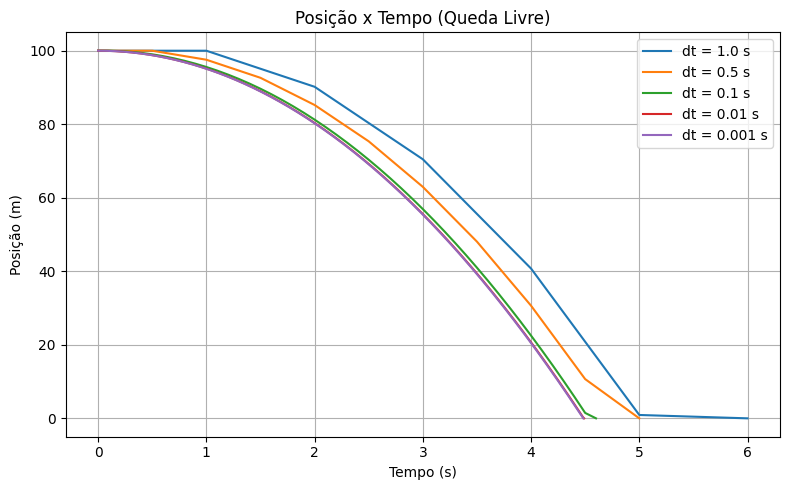

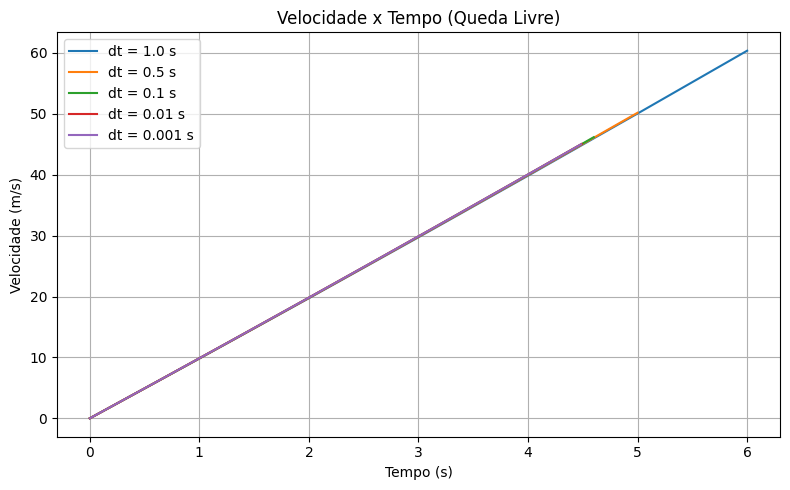

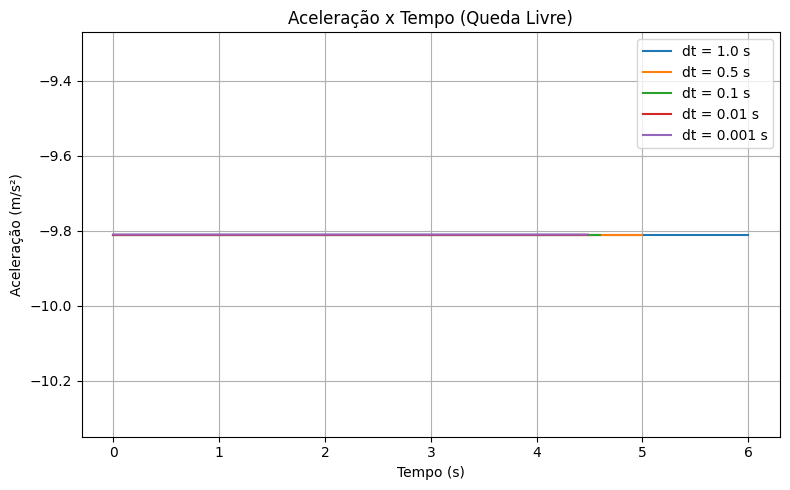

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_1_0_c_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_5_c_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_1_c_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_01_c_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_001_c_0_1.csv


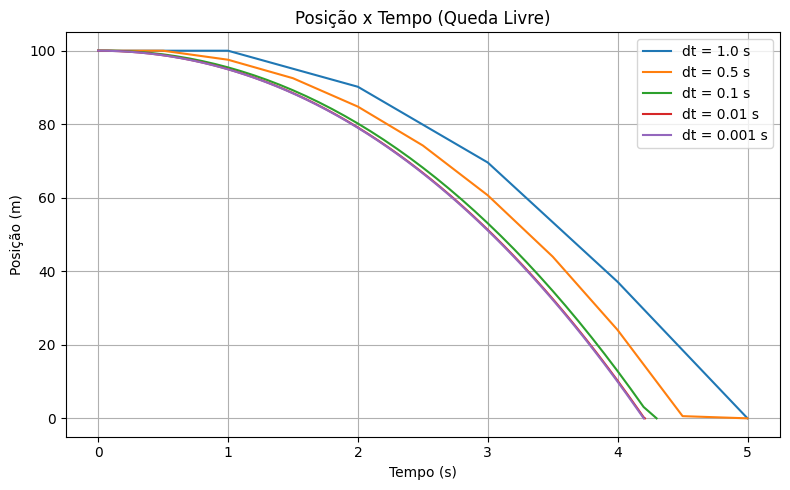

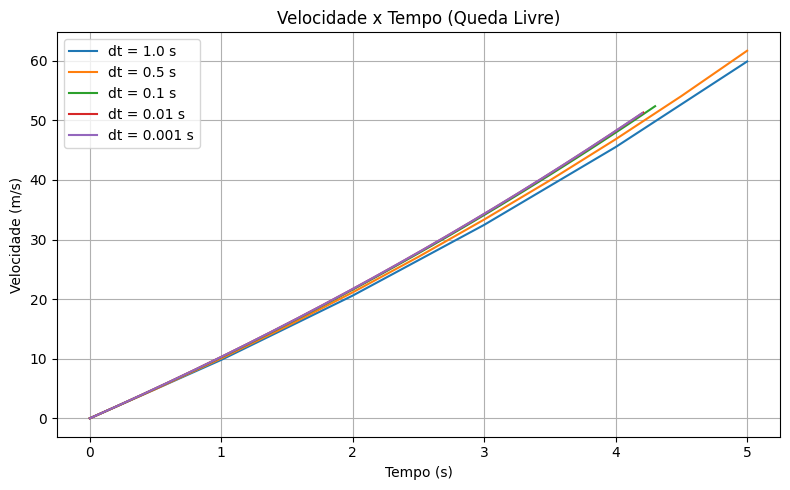

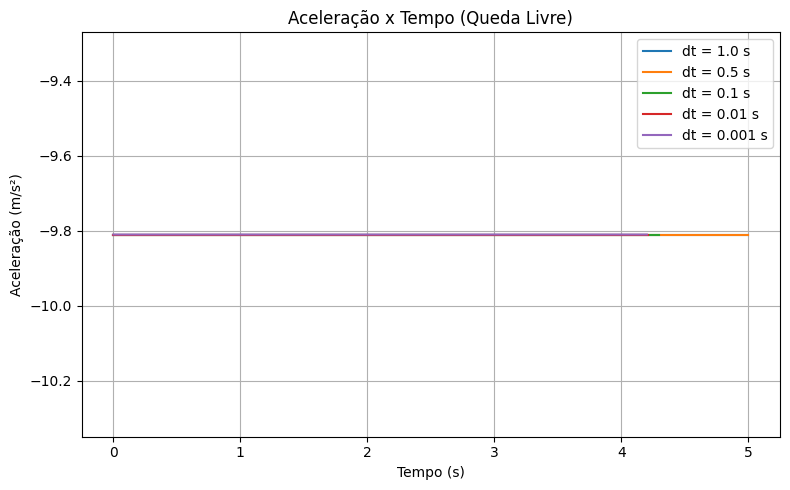

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_1_0_c_2.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_5_c_2.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_1_c_2.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_01_c_2.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_001_c_2.csv


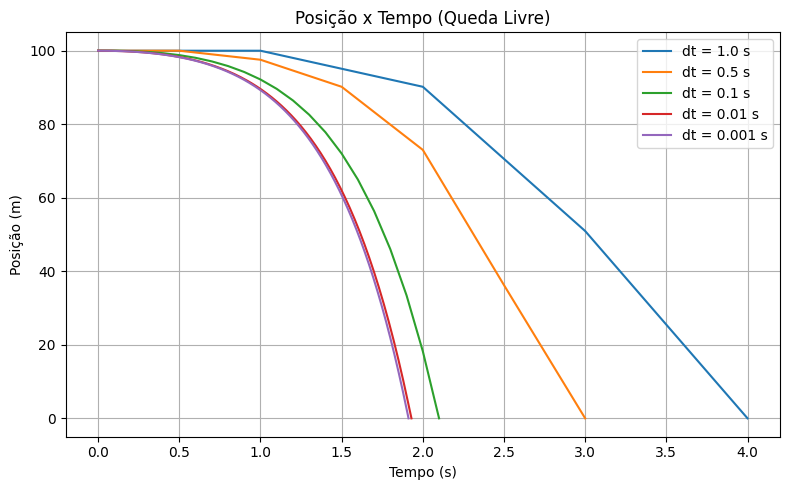

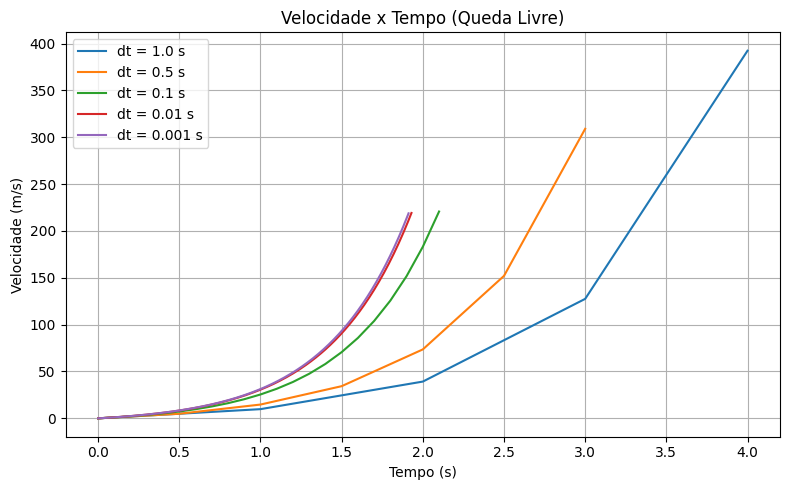

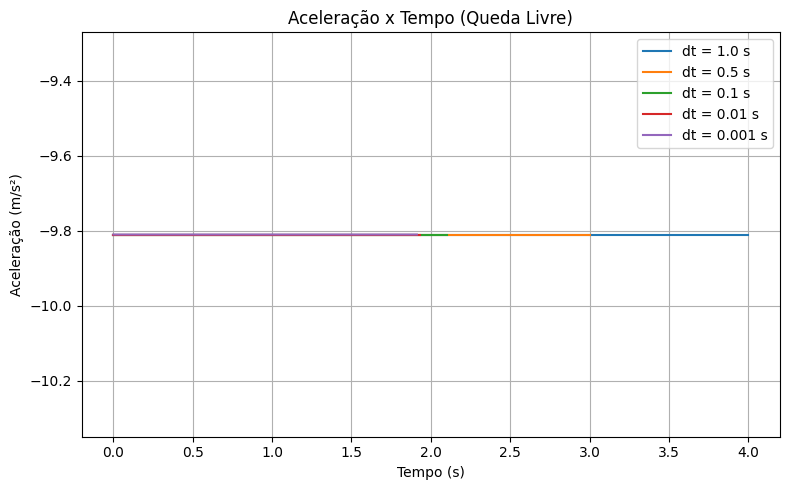

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_1_0_c_10.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_5_c_10.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_1_c_10.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_01_c_10.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_resistencia_ar\saida_queda_livre_resistencia_dt_0_001_c_10.csv


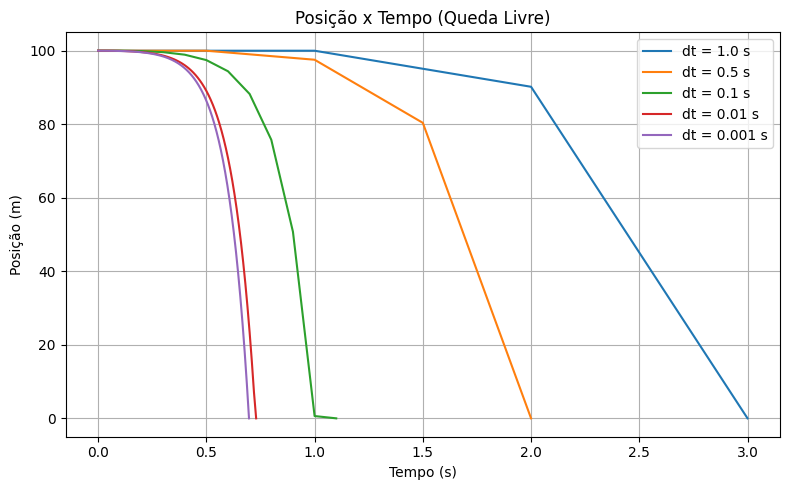

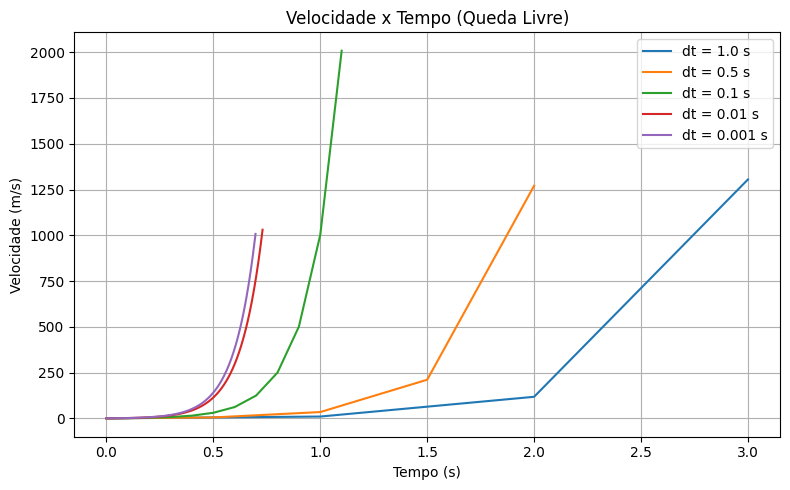

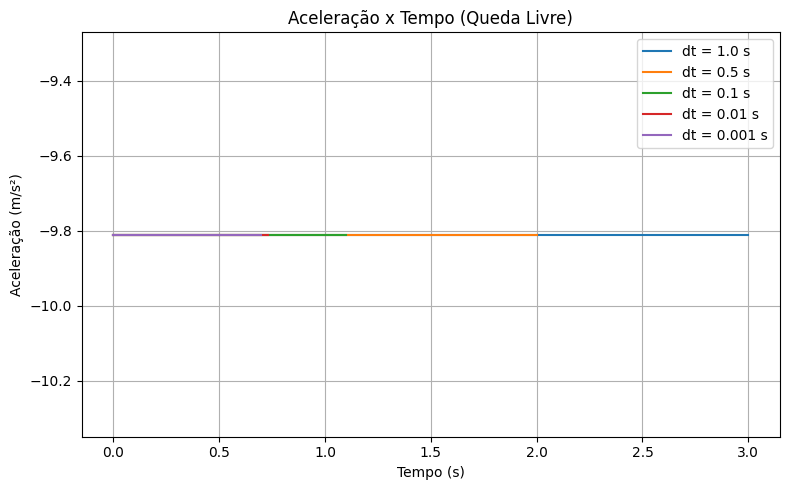

In [ ]:
for c in c_list:
    resultados_csv_resistencia = {}
    for dt in dt_list:
        df_resistencia = simula_queda_livre_resistencia(H, V, g, dt, c)
        # Monta o dicionário para plotagem diretamente
        resultados_csv_resistencia[dt] = {
            't': df_resistencia['tempo'].tolist(),
            'x': df_resistencia['posicao'].tolist(),
            'v': df_resistencia['velocidade'].tolist()
        }
        nome_arquivo = f'saida_queda_livre_resistencia_dt_{str(dt).replace(".", "_")}_c_{str(c).replace(".", "_")}.csv'
        salvar_dados(df_resistencia, output_resistencia_ar_dir, nome_arquivo)

    # Plota usando o dicionário já preenchido
    plotar_grafico_posicao_tempo(resultados_csv_resistencia, dt_list, graficos_resistencia_ar_dir, 'Queda Livre com Resistência do Ar', f'grafico_posicao_tempo_resistencia_c_{str(c).replace(".", "_")}.png')
    plotar_grafico_velocidade_tempo(resultados_csv_resistencia, dt_list, graficos_resistencia_ar_dir, 'Queda Livre com Resistência do Ar', f'grafico_velocidade_tempo_resistencia_c_{str(c).replace(".", "_")}.png')
    plotar_grafico_aceleracao_tempo(resultados_csv_resistencia, dt_list, graficos_resistencia_ar_dir, 'Queda Livre com Resistência do Ar', f'grafico_aceleracao_tempo_resistencia_c_{str(c).replace(".", "_")}.png')

### 2.4 Estudo da Acurácia no Valor Final da Velocidade

Agora vamos analisar a acurácia do valor final da velocidade ($v_{final}$) obtido numericamente para diferentes passos de tempo ($\Delta t$), comparando com o valor analítico esperado para cada caso (com e sem resistência do ar).

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_sem_resistencia.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_c_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_c_0_1.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_c_2.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_c_10.csv


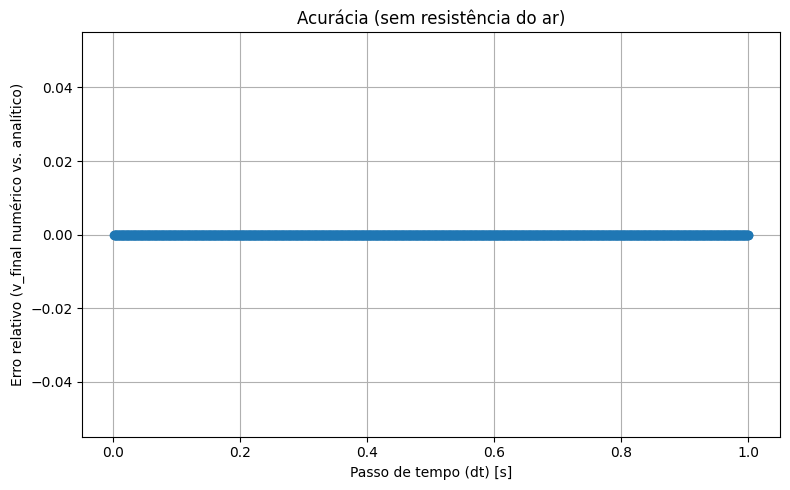

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_sem_resistencia.png


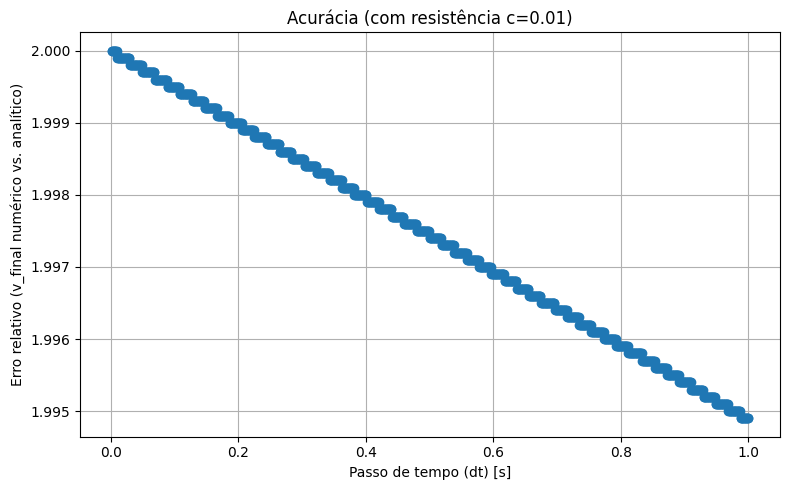

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_com_resistencia_c_0_01.png


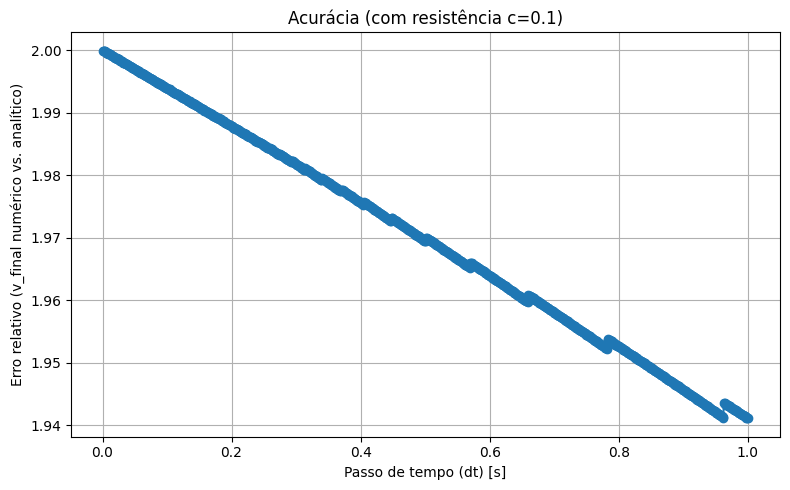

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_com_resistencia_c_0_1.png


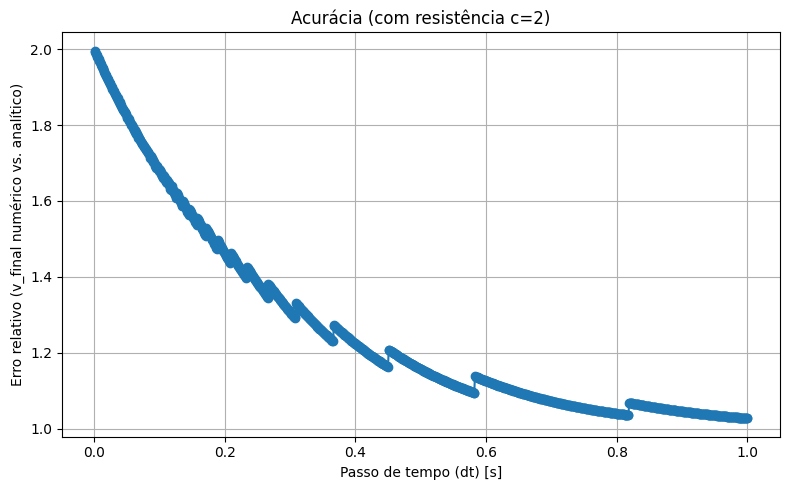

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_com_resistencia_c_2.png


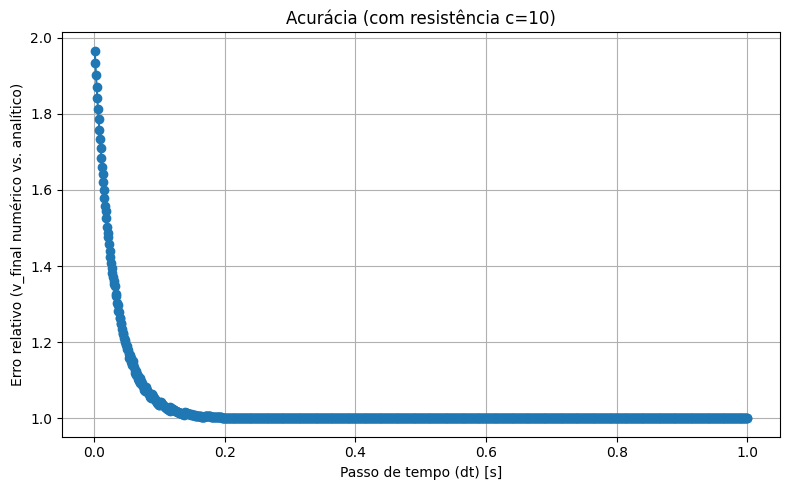

Gráfico salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos\acuracia\grafico_acuracia_com_resistencia_c_10.png


In [ ]:
# Chamada da função principal
simula_acuracia_parametrizada(
    H=H,
    V=V,
    g=g,
    dt_inicial=dt_inicial,
    dt_final=dt_final,
    dt_step=dt_step,
    c_list=c_list,
    output_acuracia_dir=output_acuracia_dir
)
# Gráfico de acurácia SEM resistência do ar
plotar_acuracia_dt_csv(
    caminho_csv=output_acuracia_dir / 'acuracia_sem_resistencia.csv',
    titulo='Acurácia (sem resistência do ar)',
    nome_arquivo='grafico_acuracia_sem_resistencia.png',
    graficos_dir=graficos_acuracia_dir
)

# Gráficos de acurácia COM resistência do ar para cada c
for c in c_list:
    nome_csv = f'acuracia_com_resistencia_c_{str(c).replace(".", "_")}.csv'
    plotar_acuracia_dt_csv(
        caminho_csv=output_acuracia_dir / nome_csv,
        titulo=f'Acurácia (com resistência c={c})',
        nome_arquivo=f'grafico_acuracia_com_resistencia_c_{str(c).replace(".", "_")}.png',
        graficos_dir=graficos_acuracia_dir
    )